# Feature Engineering

In [347]:
%load_ext IPython.extensions.autoreload
%autoreload 2

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


In [45]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 8.9 MB/s eta 0:00:00


In [424]:
import sys,os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [349]:
import numpy as np
from src.data_reader import DataSource, read_vertices_VTK, num_vertices_VTK
from src.descriptors.dscs_driver import compute_descriptors

from src.utils import get_free_id, write_jsonl, clear_jsonl

!pip install numpy==1.23.0

In [352]:
from gudhi import RipsComplex, AlphaComplex, plot_persistence_diagram
from gudhi.representations import ProminentPoints
from gudhi.representations import PersistenceImage

In [353]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report

import joblib

In [354]:
import csv

In [355]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary as torch_summary

from IPython.display import display, clear_output

from src.learning.nn import SimpleNN, train, predict

In [483]:
Model = 'Combined'

data_base = './data/data/'

save_descs_path = os.path.join(data_base,'saved_descriptors/train_set/')

data = np.load(os.path.join(save_descs_path,Model+'Data.npy'))
labels = np.load(os.path.join(save_descs_path,Model+'Labels.npy'))

print(data.shape, labels.shape)

(9244, 17) (9244,)


In [491]:
data = np.delete(data, 12, axis=1)
data.shape

(9244, 16)

In [521]:
Model = 'AlphaProminent'

data_base = './data/data/'

save_descs_path = os.path.join(data_base,'saved_descriptors/train_set/')

data2 = np.load(os.path.join(save_descs_path,Model+'Data.npy'))
#data2 = np.load(os.path.join(save_descs_path,'EncodedAlphaProminent.npy'))
labels2 = np.load(os.path.join(save_descs_path,Model+'Labels.npy'))

print(data2.shape, labels2.shape)

(9244, 75) (9244,)


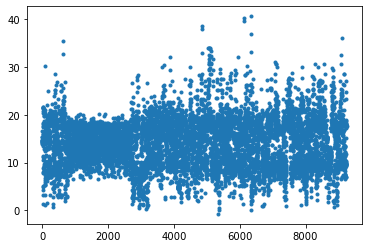

In [485]:
plt.plot(data2[:,5],'.')

In [421]:
means[25:50]

array([1.76934497e+01, 3.60303015e-01, 1.59971513e-01, 6.92511987e-02,
       1.31992064e-01, 4.51104434e+00, 1.99264002e-01, 7.94191003e-02,
       3.84670654e-02, 7.19899765e-02, 1.60228478e+00, 8.97209651e-02,
       3.33485276e-02, 1.57676032e-02, 2.99942031e-02, 7.24317167e-01,
       5.25469911e-02, 2.07076927e-02, 8.57686581e-03, 1.68881605e-02,
       3.76017596e-01, 4.64445209e-02, 1.77817983e-02, 5.92794743e-03,
       1.29447926e-02])

In [436]:
from sklearn.preprocessing import StandardScaler

In [473]:
SSc = StandardScaler()

In [480]:
data2 = SSc.fit_transform(data2, labels)

In [528]:
means = np.mean(data, axis = 0)
stds = np.std(data, axis = 0)

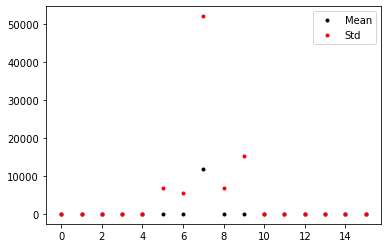

In [529]:
plt.plot(means,'.k', label='Mean')
plt.plot(stds,'.r', label='Std')
plt.legend()

### Visualize correlations

In [522]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


n, p = data2.shape[0], data2.shape[1]


# Initialize R^2 matrix
R2_matrix = np.zeros((p, p))

# Compute R^2 for each pair of features
for i in range(p):
    for j in range(p):
        if i == j:
            R2_matrix[i, j] = 1.0  # R^2 of a feature with itself is 1

        if j < i:
            R2_matrix[i, j] = R2_matrix[j, i]
        else:
            model = LinearRegression().fit(data2[:, i].reshape(-1, 1), data2[:, j])
            R2_matrix[i, j] = model.score(data2[:, i].reshape(-1, 1), data2[:, j])

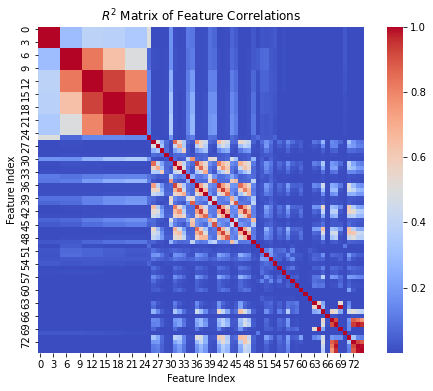

In [523]:
# Plot the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(R2_matrix, annot=False, cmap="coolwarm", fmt=".2f", square=True)
plt.title("$R^2$ Matrix of Feature Correlations")
plt.xlabel("Feature Index")
plt.ylabel("Feature Index")
plt.show()

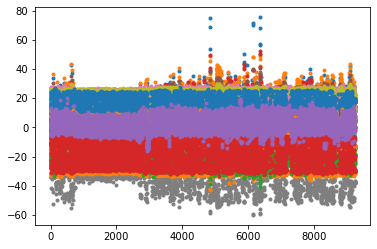

In [488]:
plt.plot(data2[:,], '.')

In [524]:
n, p = data.shape[0], data.shape[1]


# Initialize R^2 matrix
R2_matrix = np.zeros((p, p))

# Compute R^2 for each pair of features
for i in range(p):
    for j in range(p):
        if i == j:
            R2_matrix[i, j] = 1.0  # R^2 of a feature with itself is 1
        if j < i:
            R2_matrix[i, j] = R2_matrix[j, i]
        else:
            model = LinearRegression().fit(data[:, i].reshape(-1, 1), data[:, j])
            R2_matrix[i, j] = model.score(data[:, i].reshape(-1, 1), data[:, j])

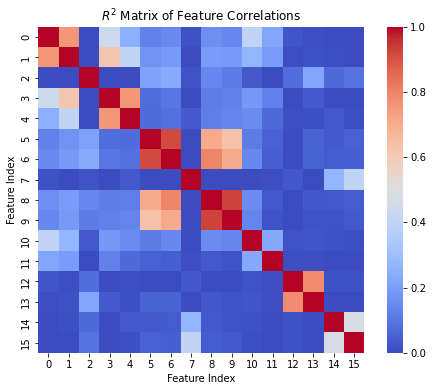

In [525]:
# Plot the matrix
plt.figure(figsize=(8, 6))
sns.heatmap(R2_matrix, annot=False, cmap="coolwarm", fmt=".2f", square=True)
plt.title("$R^2$ Matrix of Feature Correlations")
plt.xlabel("Feature Index")
plt.ylabel("Feature Index")
plt.show()

### Try to decorrelate quantiles

In [316]:
for i in [4,3,2,1]:
    data[:,i] -= data[:,i-1]

In [317]:
for i in [9,8,7,6]:
    data[:,i] -= data[:,i-1]

### Try with linear regression

In [494]:
for i in [0,1,3,4]:
    reg = LinearRegression().fit(data[:, [2]], data[:, i])

    # Compute residuals
    res = data[:, i] - reg.predict(data[:, [2]])

    # substitute
    data[:,i] = res


In [495]:
for i in [5,6,8,9]:
    reg = LinearRegression().fit(data[:, [7]], data[:, i])

    # Compute residuals
    res = data[:, i] - reg.predict(data[:, [7]])

    # substitute
    data[:,i] = res

In [246]:
class_mask = np.where(labels==80)[0]

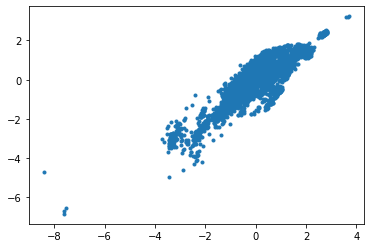

In [462]:
plt.plot(data[:,0], data[:,1], '.')

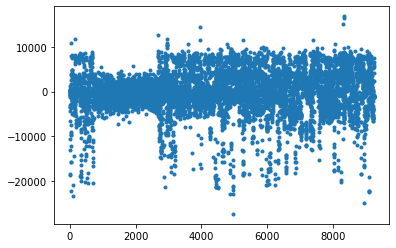

In [339]:
plt.plot( data[:,7], '.')

### Combine

In [531]:
all_data = np.concatenate([data, data2], axis=1)
#all_data = data

all_data.shape

(9244, 91)

### Cross-validation

In [538]:
StrShSp = StratifiedShuffleSplit(n_splits=15, train_size=0.8, random_state=None)

# get indices of split
train_idx, val_idx = next(StrShSp.split(all_data, labels))

train_data = all_data[train_idx,:]
train_labels = labels[train_idx]

val_data = all_data[val_idx]
val_labels = labels[val_idx]

In [533]:
N_Estimators = 150
criterion = 'entropy'


forest = RandomForestClassifier(n_estimators=N_Estimators, criterion=criterion)
forest.fit(train_data, train_labels)

RandomForestClassifier(criterion='entropy', n_estimators=150)

In [539]:
pred_labels = forest.predict(val_data)

In [540]:
acc = accuracy_score(val_labels, pred_labels)

print(acc)

0.9772850189291509


In [536]:
print(classification_report(val_labels, pred_labels, zero_division=0.0))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.00      0.00      0.00         1
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         4
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00        25
           6       1.00      1.00      1.00         5
           7       0.88      0.93      0.90        15
           8       0.98      1.00      0.99       411
           9       1.00      0.92      0.96        13
          10       0.67      0.67      0.67         3
          11       0.90      1.00      0.95         9
          12       1.00      0.50      0.67         2
          13       1.00      0.75      0.86         4
          14       0.67      0.87      0.76        98
          15       0.86      1.00      0.92        18
          16       0.90      0.90      0.90        31
          17       0.92    

In [346]:
np.save('ThisData.npy',np.delete(data, 12 , axis=1))

## Notes
For the **sublevel set filtration**
- In sublevelset **there is no H_2**
- Using only `quantiles[0]` and `charge[0]` yelds 68%, but using all quantiles and all charges yields 84.5%.
So maybe use more steps! A finer subdivision of the steps.
- It also seems that the more important parts of the quantile function are those close to the **extremes**
- Also, maybe move to the residuals wrt a linear regression

For the **Alpha filtration**
- With 5x5 persistent images, using all 75 columns yields 63%, using only every fifth column yields 60%